In [20]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

In [21]:
df = pd.read_csv('../data/csv/processed_data.csv')

Number of components for 95% variance: 18


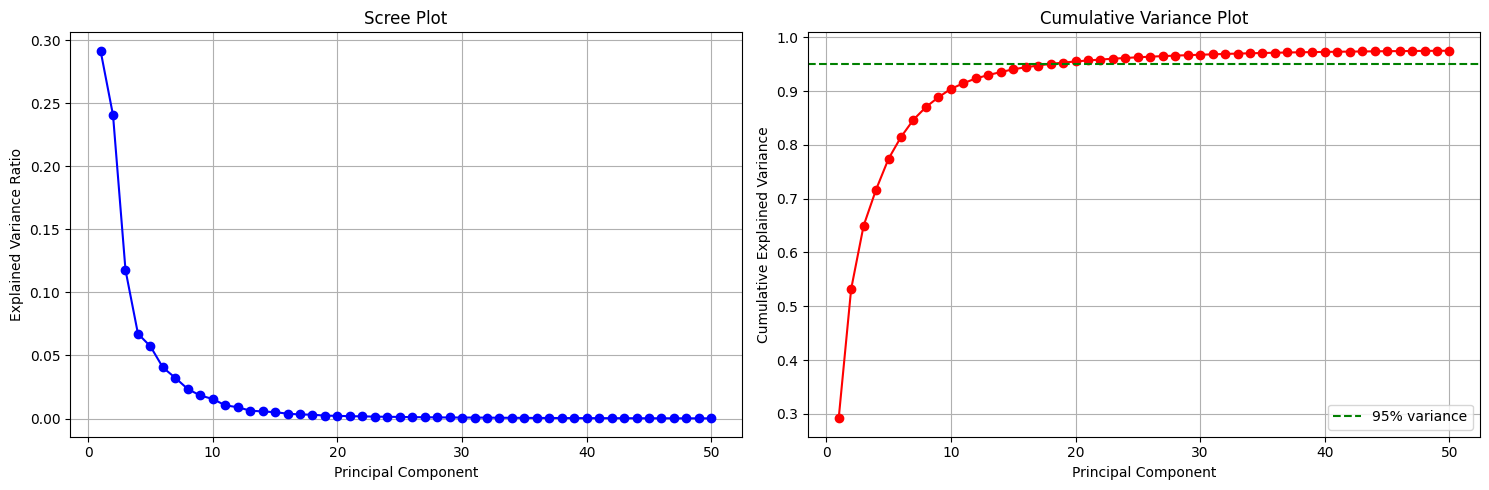

In [23]:
# Separate features from metadata
metadata_cols = ['tire_number', 'origin', 'measurement_id']
X = df.drop(columns=metadata_cols)

# Perform PCA
pca = PCA()
pca.fit(X)

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find number of components for 95% and 99% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
# n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"Number of components for 95% variance: {n_components_95}")
# print(f"Number of components for 99% variance: {n_components_99}")

# Create scree plot
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot explained variance ratio
ax1.plot(range(1, min(51, len(pca.explained_variance_ratio_) + 1)), 
         pca.explained_variance_ratio_[:50], 'bo-')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Scree Plot')
ax1.grid(True)

# Plot cumulative variance
ax2.plot(range(1, min(51, len(cumulative_variance) + 1)), 
         cumulative_variance[:50], 'ro-')
ax2.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
# ax2.axhline(y=0.99, color='b', linestyle='--', label='99% variance')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Variance Plot')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()